In [31]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv(r"C:\Users\smadh\OneDrive\Desktop\New_Project_Folder\Big Mart Sales Prediction\train_v9rqX0R (1).csv")

In [9]:
df.head(50)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [12]:
df["Item_Weight"].fillna(df["Item_Weight"].median(), inplace=True)


C:\Users\smadh\AppData\Local\Temp\ipykernel_20952\3139995016.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Item_Weight"].fillna(df["Item_Weight"].median(), inplace=True)


In [13]:
df['Outlet_Size'].fillna('Others', inplace=True)


C:\Users\smadh\AppData\Local\Temp\ipykernel_20952\3101203157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outlet_Size'].fillna('Others', inplace=True)


In [14]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [16]:
cat_cols = df.dtypes[df.dtypes=='object'].index
num_cols = df.dtypes[df.dtypes!='object'].index


In [17]:
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [18]:
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [19]:
cols_2encode = [ 'Item_Fat_Content','Item_Type','Outlet_Size','Outlet_Location_Type','Outlet_Type']

In [20]:
df_dummies = pd.get_dummies(data=df,columns = cols_2encode,dtype=int,drop_first=True)


In [21]:
X = df_dummies.drop(['Item_Identifier','Outlet_Identifier','Item_Outlet_Sales'],axis=1)
y = df_dummies['Item_Outlet_Sales']

In [22]:
print(X.shape,y.shape)


(8523, 31) (8523,)


In [23]:
from sklearn.model_selection import train_test_split 

In [24]:
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size = 0.3,random_state=42)


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *

In [26]:
lr1 = LinearRegression()
lr1.fit(X_train,y_train)

LinearRegression()

In [27]:
y_pred=  lr1.predict(X_test)


In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 810.3396290806788
MSE : 1210615.4343360488
RMSE : 1100.2797073181205
R2 Score : 0.567790706222566


In [29]:
### DT

In [30]:
y_pred = dt.predict(X_test)

NameError: name 'dt' is not defined

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test,y_pred))

 # Improvement 1

In [32]:
df1 = pd.read_csv(r"C:\Users\smadh\OneDrive\Desktop\New_Project_Folder\Big Mart Sales Prediction\train_v9rqX0R (1).csv")

In [33]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### 1️. Better Missing Value Imputation (Instead of 0)

In [34]:
#Items with the same identifier usually have the same weight.
df1['Item_Weight'] = df1.groupby('Item_Identifier')['Item_Weight']\
.transform(lambda x: x.fillna(x.mean()))

In [35]:
df1.isnull().sum()

Item_Identifier                 0
Item_Weight                     4
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [36]:
# Still missing
df1['Item_Weight'].fillna(df1['Item_Weight'].mean(), inplace=True)

C:\Users\smadh\AppData\Local\Temp\ipykernel_20952\2908451380.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Item_Weight'].fillna(df1['Item_Weight'].mean(), inplace=True)


In [37]:
df1.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [38]:
# Impute Outlet_Size using Mode of Outlet Type
df1['Outlet_Size'] = df1.groupby('Outlet_Type')['Outlet_Size']\
.transform(lambda x: x.fillna(x.mode()[0]))

In [39]:
df1.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

### Feature Engineering

Creating Item_Category<br>
First two letters of Item_Identifier can be used as item_category

In [40]:
df1['Item_Category'] = df1['Item_Identifier'].str[:2]

df1['Item_Category'] = df1['Item_Category'].map({
'FD':'Food',
'DR':'Drinks',
'NC':'Non-Consumable'
})

Fixing Fat Content Inconsistency

In [41]:
df1['Item_Fat_Content'] = df1['Item_Fat_Content'].replace({
'LF':'Low Fat',
'low fat':'Low Fat',
'reg':'Regular'
})

In [42]:
df1.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Category
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Food
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Drinks
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Food
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,Food
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable


Non-Consumables items Should Not Have Fat

In [43]:
df1.loc[df1['Item_Category']=='Non-Consumable','Item_Fat_Content'] = 'Non Edible'

### Creating Store Age Feature<br>
As Older stores often have higher sales.

In [44]:
df1['Outlet_Age'] = 2026 - df1['Outlet_Establishment_Year']

In [45]:
df1.drop('Outlet_Establishment_Year',axis=1,inplace=True)

### Note
1 Load Data<br>
2 Handle Missing Values<br>
3 Train-Test Split<br>
4 Cap Outliers (on training data)<br>
5 Train Model<br>

Otherwise you introduce data leakage.

### 3️. Outlier Treatment

In [46]:
num_cols = df1.select_dtypes(exclude='object').columns


In [47]:
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales',
       'Outlet_Age'],
      dtype='object')

In [48]:
df2 = df1[num_cols].describe(percentiles=[0.01,0.02,0.03,0.05,0.95,0.97,0.98,0.99]).T  # T = transpose
df2

,count,mean,std,min,1%,2%,3%,5%,50%,95%,97%,98%,99%,max
Item_Weight,8523.0,12.875420,4.645008,4.555,5.150000,5.405000,5.655000,5.9400,12.650000,20.25000,20.600000,20.700000,20.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.000000,0.000000,0.000000,0.0000,0.053931,0.16378,0.176373,0.187488,0.226249,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,35.062752,37.219000,38.750600,42.5167,143.012800,250.76924,257.143744,260.445496,263.022600,266.888400
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,83.890800,115.476352,145.583828,188.4214,1794.331000,5522.81100,6094.307088,6623.831144,7366.011720,13086.964800
Outlet_Age,8523.0,28.168133,8.371760,17.000,17.000000,17.000000,17.000000,17.0000,27.000000,41.00000,41.000000,41.000000,41.000000,41.000000


Outliers are only in Item_Outlet_Sales

<Axes: xlabel='Item_Outlet_Sales'>

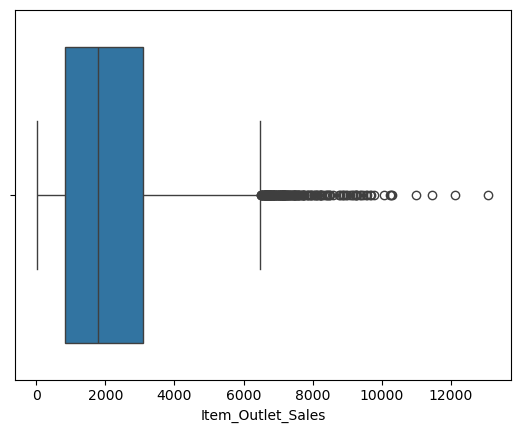

In [49]:
import seaborn as sns
sns.boxplot(x=df1['Item_Outlet_Sales'])

In [50]:
lower = df1['Item_Outlet_Sales'].quantile(0.01)
upper = df1['Item_Outlet_Sales'].quantile(0.99)

In [51]:
df1['Item_Outlet_Sales'] = df1['Item_Outlet_Sales'].clip(lower, upper)

In [52]:
# Comparison
print(df1['Item_Outlet_Sales'].describe())

count    8523.000000
mean     2170.021590
std      1663.002754
min        83.890800
25%       834.247400
50%      1794.331000
75%      3101.296400
max      7366.011720
Name: Item_Outlet_Sales, dtype: float64


<Axes: xlabel='Item_Outlet_Sales'>

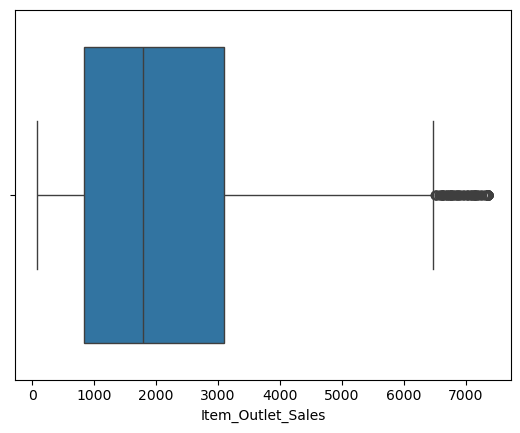

In [53]:
sns.boxplot(x=df1['Item_Outlet_Sales'])

### 4️.Encoding

In [54]:
cat_cols = df1.select_dtypes(include='object').columns
cat_cols


Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'],
      dtype='object')

In [55]:
cols_2encode = [ 'Item_Fat_Content','Item_Type','Outlet_Size','Outlet_Location_Type','Outlet_Type','Item_Category']


In [56]:
df1 = pd.get_dummies(df1,columns=cols_2encode,drop_first=True)

### 5️. Define X and y

In [57]:
df1.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Non Edible,Item_Fat_Content_Regular,Item_Type_Breads,...,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Category_Food,Item_Category_Non-Consumable
0,FDA15,9.30,0.016047,249.8092,OUT049,3735.1380,27,False,False,False,...,False,True,False,False,False,True,False,False,True,False
1,DRC01,5.92,0.019278,48.2692,OUT018,443.4228,17,False,True,False,...,False,True,False,False,True,False,True,False,False,False
2,FDN15,17.50,0.016760,141.6180,OUT049,2097.2700,27,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,FDX07,19.20,0.000000,182.0950,OUT010,732.3800,28,False,True,False,...,False,False,True,False,True,False,False,False,True,False
4,NCD19,8.93,0.000000,53.8614,OUT013,994.7052,39,True,False,False,...,False,False,False,False,True,True,False,False,False,True


In [58]:
X = df1.drop(['Item_Outlet_Sales','Item_Identifier','Outlet_Identifier'],axis=1)

y = df1['Item_Outlet_Sales']

In [59]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [61]:
y_pred = model.predict(X_test)

### Evaluation

In [62]:
from sklearn.metrics import *

print("MAE:",mean_absolute_error(y_test,y_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

print("R2:",r2_score(y_test,y_pred))

MAE: 783.1465152212631
RMSE: 1040.6341364395175
R2: 0.5855351389006299


### Decision Tree model

In [63]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score 
import numpy as np

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [64]:

pred = dt.predict(X_test)

In [65]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test,pred))

RMSE: 1438.9488229816866
R2: 0.2075310105664504


In [66]:
# Tuning Decision Tree
dt = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt.fit(X_train, y_train)

pred = dt.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

RMSE: 1043.8815613842614
R2: 0.5829443270650331


In [67]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[5,7,9,12],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,5,10],
    'max_features':[None,'sqrt','log2']
}

dt = DecisionTreeRegressor(random_state=42)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 20}


C:\Users\smadh\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [68]:
best_dt = grid.best_estimator_

pred = best_dt.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

RMSE: 1015.2395526191029
R2: 0.6055166858733553


### Random Forest

In [69]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)



RandomForestRegressor(max_depth=10, n_estimators=300, random_state=42)

In [70]:
pred = rf.predict(X_test)


In [71]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

RMSE: 1011.7268215566608
R2: 0.6082417895224634


In [72]:
# Hyper parameter Tuning

In [73]:
 from sklearn.model_selection import GridSearchCV

 params = {
 'n_estimators':[100,200],
 'max_depth':[5,6,7,8,10],
 'min_samples_split':[2,5,7],
 'min_samples_leaf':[1,2,4,5]
 }



In [74]:
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                     params,
                     cv=5,
                     scoring='neg_root_mean_squared_error')



In [75]:
 grid.fit(X_train,y_train)



GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 6, 7, 8, 10],
                         'min_samples_leaf': [1, 2, 4, 5],
                         'min_samples_split': [2, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [76]:
 print(grid.best_params_)

{'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 200}


In [78]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=1,
    min_samples_split=7,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=6, min_samples_split=7, n_estimators=200,
                      random_state=42)

In [79]:
pred = rf.predict(X_test)


In [80]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))

RMSE: 992.4153419232765
R2: 0.6230545382324846


In [ ]:
### XG Boost

In [81]:
 # from xgboost import XGBRegressor
 # from sklearn.metrics import mean_squared_error, r2_score

 # xgb = XGBRegressor(
 #    n_estimators=300,
 #     learning_rate=0.05,
 #     max_depth=6,
 #     subsample=0.8,
 #     colsample_bytree=0.8,
 #     random_state=42
 # )
 # xgb.fit(X_train, y_train)

 # pred = xgb.predict(X_test)

 # print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
 # print("R2:", r2_score(y_test, pred))

RMSE: 1039.489841640552
R2: 0.5864461396291225


In [82]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[200,300,400],
    'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1]
}

xgb = XGBRegressor(random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)

C:\Users\smadh\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.7}


In [83]:
best_xgb = grid.best_estimator_

pred = best_xgb.predict(X_test)

print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
print("R2:",r2_score(y_test,pred))

RMSE: 995.8065939769579
R2: 0.6204739630827416
